# Gulf Stream CHL & ADT Climatology

NOTE: This was not run on CryoCloud due to the file sizes of the original satellite data. 

This script takes CHLA and SLA satelltie data from 2000-2020, calculates monthly averages, crops to the Gulf Stream region, interpolates them to the same 1/4 degree grids, and saves the data as an xarray dataset. 

LJK

Date created: 04/21/25

Last edited: 05/30/25

In [1]:
import os
import numpy as np
from netCDF4 import Dataset
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [2]:
fontsize = 18

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure title

In [3]:
#input_dir = '/nfs/micklab005/jonesae/gradients4/CMEMS_data/'
input_dir = '/nfs/micklab005/jonesae/NP_2000_to_2020/CMEMS_data/'

# Set up empty array to add the daily SLA 
#sample_sla = xr.open_dataset(input_dir + 'dt_global_allsat_phy_l4_20210101.nc')
sample_sla = xr.open_dataset(input_dir + 'dt_global_allsat_phy_l4_20130412.nc')
sample_sla

<xarray.Dataset> Size: 58MB
Dimensions:    (time: 1, latitude: 720, nv: 2, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 8B 2013-04-12
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
  * nv         (nv) int32 8B 0 1
Data variables:
    crs        int32 4B ...
    lat_bnds   (latitude, nv) float32 6kB ...
    lon_bnds   (longitude, nv) float32 12kB ...
    err        (time, latitude, longitude) float64 8MB ...
    adt        (time, latitude, longitude) float64 8MB ...
    ugos       (time, latitude, longitude) float64 8MB ...
    vgos       (time, latitude, longitude) float64 8MB ...
    sla        (time, latitude, longitude) float64 8MB ...
    ugosa      (time, latitude, longitude) float64 8MB ...
    vgosa      (time, latitude, longitude) float64 8MB ...
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-4 sea su...
    time_coverage_duration:          P1D
    time_coverage_end:               2013-04-12T00:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2013-04-12T00:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...

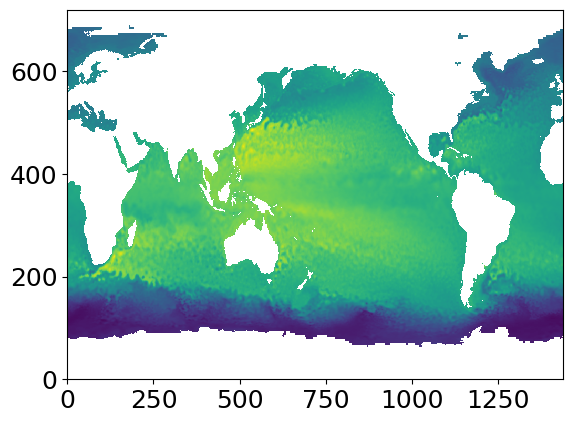

In [4]:
plt.pcolormesh(sample_sla.adt[0])

Dimension edges is just used to properly plot with pcolormesh

In [5]:
def dimension_edges(dim_array):
    adjustment = float(dim_array[1]-dim_array[0])/2
    adjusted_array = [float(i)-adjustment for i in dim_array]
    adjusted_array.append(dim_array[-1]+adjustment)
    return np.array(adjusted_array)

In [6]:
sample_sla_lon_edges = dimension_edges(sample_sla.longitude)
sample_sla_lat_edges = dimension_edges(sample_sla.latitude)

lon_min,lon_max = 280, 300
lat_min,lat_max = 32, 42

lon_inds = np.where((sample_sla_lon_edges >= lon_min) & (sample_sla_lon_edges <= lon_max))
lat_inds = np.where((sample_sla_lat_edges >= lat_min) & (sample_sla_lat_edges <= lat_max))

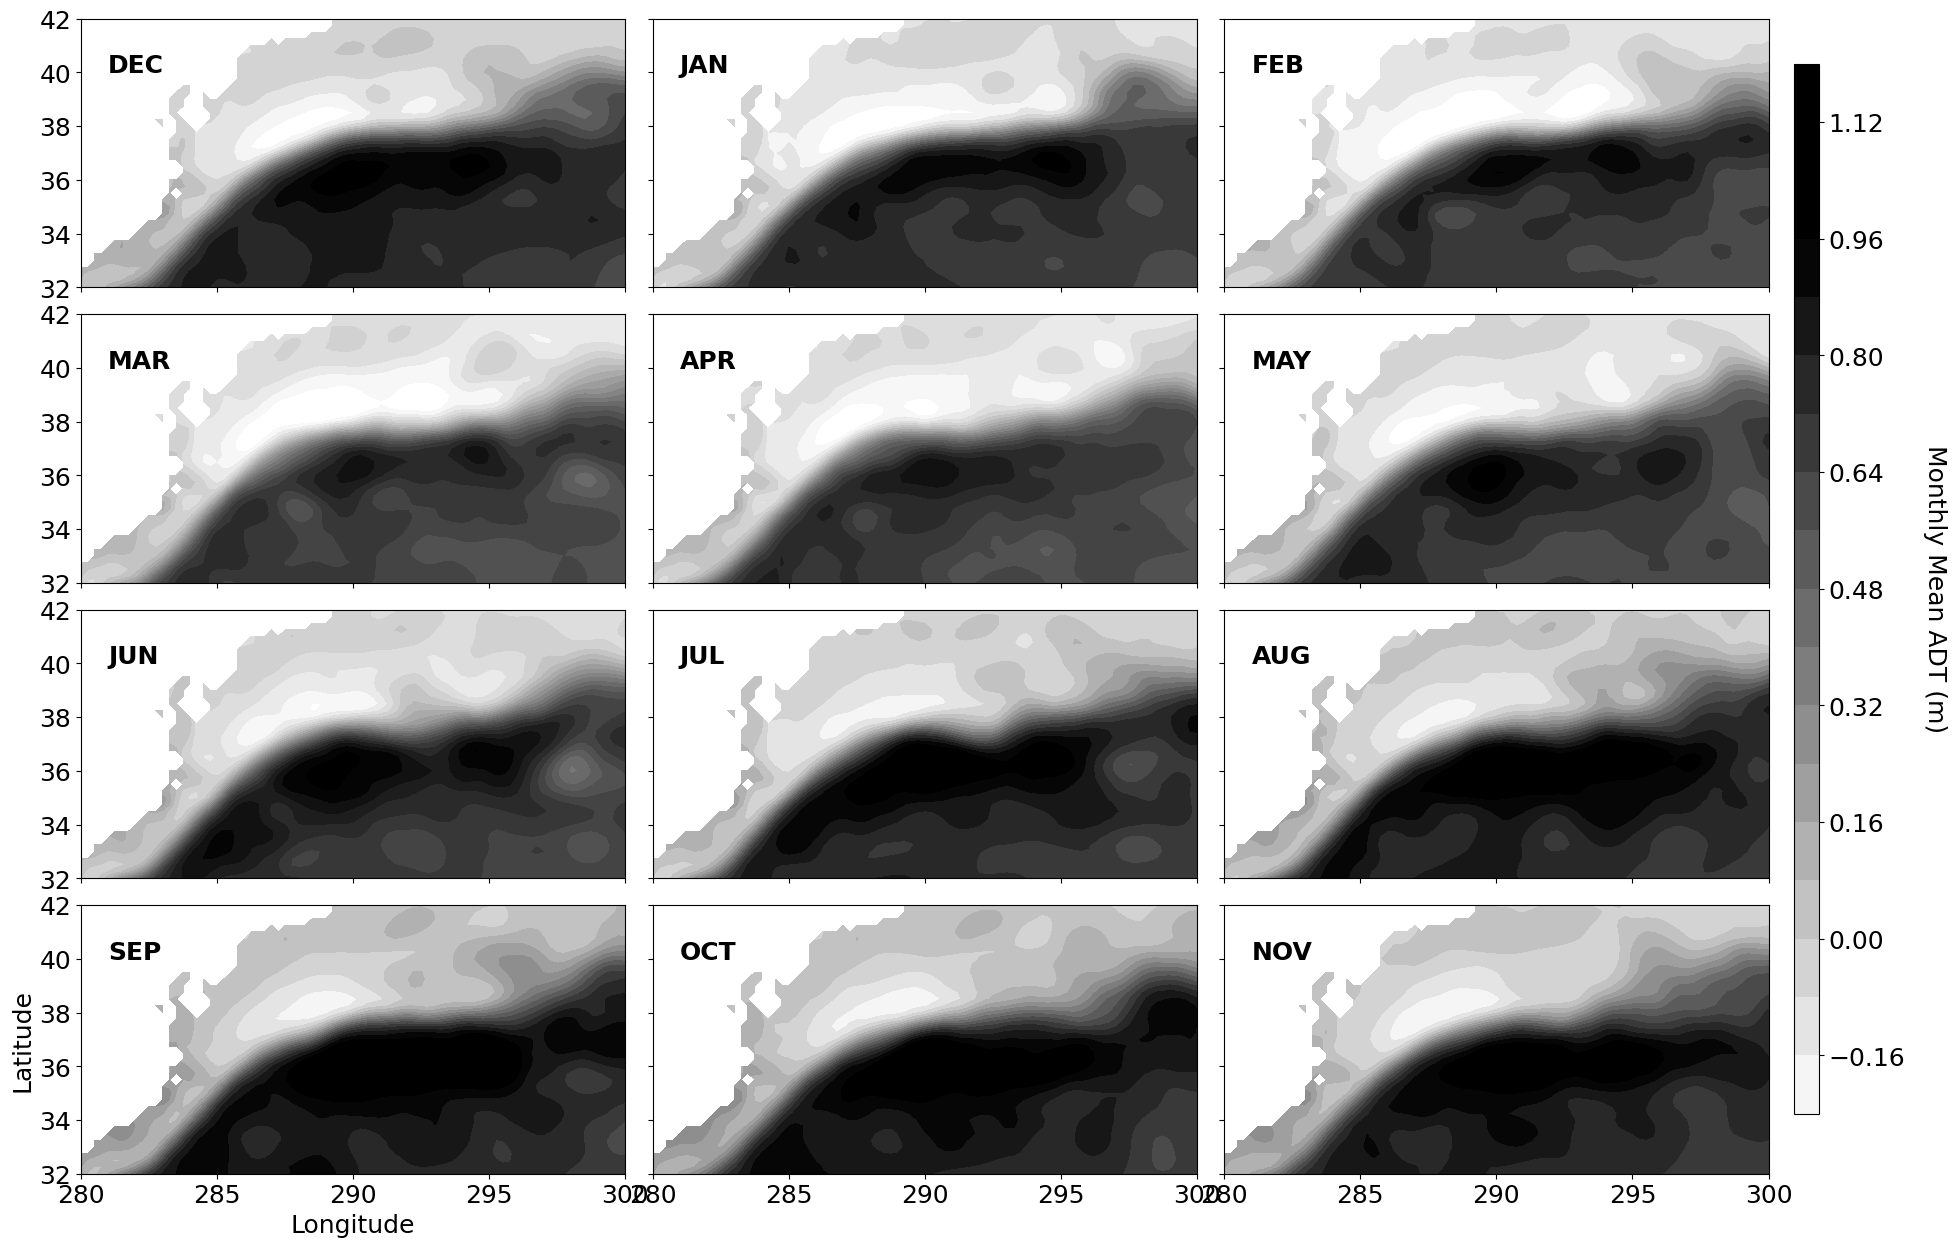

In [8]:
fig,ax = plt.subplots(4,3,figsize=(25,15))
plt.subplots_adjust(wspace=0.05, hspace=0.1) # make plots closer together

month_list = ['01','02','03','04','05','06','07','08','09','10','11','12']
months = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']

#ADT_avg = np.load('/nfs/micklab005/jonesae/NP_2000_to_2020/CMEMS_data/climatology/dt_global_allsat_phy_l4_2010_2019_month_01_AVG.npy')


def plot_row_by_season(row_ind,array_of_months):
    i = 0
    for m in array_of_months:
        ADT_avg = np.load('/nfs/micklab005/jonesae/NP_2000_to_2020/CMEMS_data/climatology/dt_global_allsat_phy_l4_2010_2019_month_%s_AVG.npy'%(m))
        plot = ax[row_ind,i].contourf(sample_sla_lon_edges[lon_inds],sample_sla_lat_edges[lat_inds],np.array(ADT_avg)[lat_inds[0],:][:,lon_inds[0]],
                                        cmap='binary',levels=20,vmin=-0.25,vmax=0.95)
        ax[row_ind,i].text(281,40,months[month_list.index(m)],color='k',fontweight='bold')
        i += 1
    return plot

plot = plot_row_by_season(0,['12','01','02']) # Winter
plot = plot_row_by_season(1,['03','04','05']) # Spring
plot = plot_row_by_season(2,['06','07','08']) # Summer
plot = plot_row_by_season(3,['09','10','11']) # Fall

# Colorbar
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.81, 0.15, 0.01, 0.7]) #[left, bottom, width, height]
fig.colorbar(plot, cax=cbar_ax, extend='both')
cbar_ax.set_ylabel('Monthly Mean ADT (m)', rotation=270)
cbar_ax.get_yaxis().labelpad = 30


ax[3,0].set_xlabel('Longitude')
ax[3,0].set_ylabel('Latitude')

for row in range(4):
    for col in range(3):
        if row != 3:
            ax[row,col].set_xticklabels([])
        if col != 0:
            ax[row,col].set_yticklabels([])

plt.show()

### OC-CCI Monthly Chl-a 

In [9]:
chl_dir = '/pool001/jonesae/PACEhackweek/monthly_chl/'
sample_chl = xr.open_dataset(chl_dir + 'ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHLY_4km_GEO_PML_OCx-201612-fv6.0.nc')
sample_chl

<xarray.Dataset> Size: 1GB
Dimensions:             (time: 1, lat: 4320, lon: 8640)
Coordinates:
  * lat                 (lat) float64 35kB 89.98 89.94 89.9 ... -89.94 -89.98
  * lon                 (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 180.0
  * time                (time) datetime64[ns] 8B 2016-12-01
Data variables:
    MERIS_nobs_sum      (time, lat, lon) float32 149MB ...
    MODISA_nobs_sum     (time, lat, lon) float32 149MB ...
    OLCI-A_nobs_sum     (time, lat, lon) float32 149MB ...
    OLCI-B_nobs_sum     (time, lat, lon) float32 149MB ...
    SeaWiFS_nobs_sum    (time, lat, lon) float32 149MB ...
    VIIRS_nobs_sum      (time, lat, lon) float32 149MB ...
    chlor_a             (time, lat, lon) float32 149MB ...
    chlor_a_log10_bias  (time, lat, lon) float32 149MB ...
    chlor_a_log10_rmsd  (time, lat, lon) float32 149MB ...
    crs                 int32 4B ...
    total_nobs_sum      (time, lat, lon) float32 149MB ...
Attributes: (12/51)
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    cdm_data_type:                     Grid
    comment:                           See summary attribute
    creator_email:                     help@esa-oceancolour-cci.org
    creator_name:                      Plymouth Marine Laboratory
    ...                                ...
    license:                           ESA CCI, EOCIS, and C3S Data Policy: f...
    project:                           Climate Change Initiative - European S...
    references:                        https://climate.esa.int/en/projects/oc...
    title:                             ESA CCI, EOCIS Ocean Colour Product, a...
    summary:                           Data products generated by the Ocean C...
    tracking_id:                       7dec767b-50f4-4830-a2c2-5e9c36448747

This takes a hot min

In [10]:
chl_dir = '/pool001/jonesae/PACEhackweek/monthly_chl/'
main_files = [f for f in os.listdir(chl_dir) if (f.startswith('ESACCI') & f.endswith('.nc'))]
month_list = ['01','02','03','04','05','06','07','08','09','10','11','12']

month_chl_avg = []

for i in np.arange(0,len(month_list)):
    print(i)

    month_filenames = [f for f in main_files if (f[-11:-9] == month_list[i])]    
    month_chl = []
    for filename in month_filenames:
        temp_chl = xr.open_dataset(chl_dir + filename)
        month_chl.append(temp_chl.chlor_a[0])
    month_chl_avg.append(np.nanmean(month_chl,axis=0))

0


/tmp/ipykernel_22510/3757193339.py:15: RuntimeWarning: Mean of empty slice
  month_chl_avg.append(np.nanmean(month_chl,axis=0))


1


/tmp/ipykernel_22510/3757193339.py:15: RuntimeWarning: Mean of empty slice
  month_chl_avg.append(np.nanmean(month_chl,axis=0))


2


...

/tmp/ipykernel_22510/3757193339.py:15: RuntimeWarning: Mean of empty slice
  month_chl_avg.append(np.nanmean(month_chl,axis=0))


10


/tmp/ipykernel_22510/3757193339.py:15: RuntimeWarning: Mean of empty slice
  month_chl_avg.append(np.nanmean(month_chl,axis=0))


11


/tmp/ipykernel_22510/3757193339.py:15: RuntimeWarning: Mean of empty slice
  month_chl_avg.append(np.nanmean(month_chl,axis=0))


In [11]:
chl_lon_edges = dimension_edges(sample_chl.lon)
chl_lat_edges = dimension_edges(sample_chl.lat)

lon_min,lon_max = -80, -60
lat_min,lat_max = 32, 42

chl_lon_inds = np.where((chl_lon_edges >= lon_min) & (chl_lon_edges <= lon_max))
chl_lat_inds = np.where((chl_lat_edges >= lat_min) & (chl_lat_edges <= lat_max))

In [12]:
np.nanmin(month_chl_avg)

np.float32(0.001)

<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_22510/3575007096.py:27: SyntaxWarning: invalid escape sequence '\c'
  cbar_ax.set_ylabel('Monthly Mean Chl-a ($mg\cdot m^{-3}$)', rotation=270)


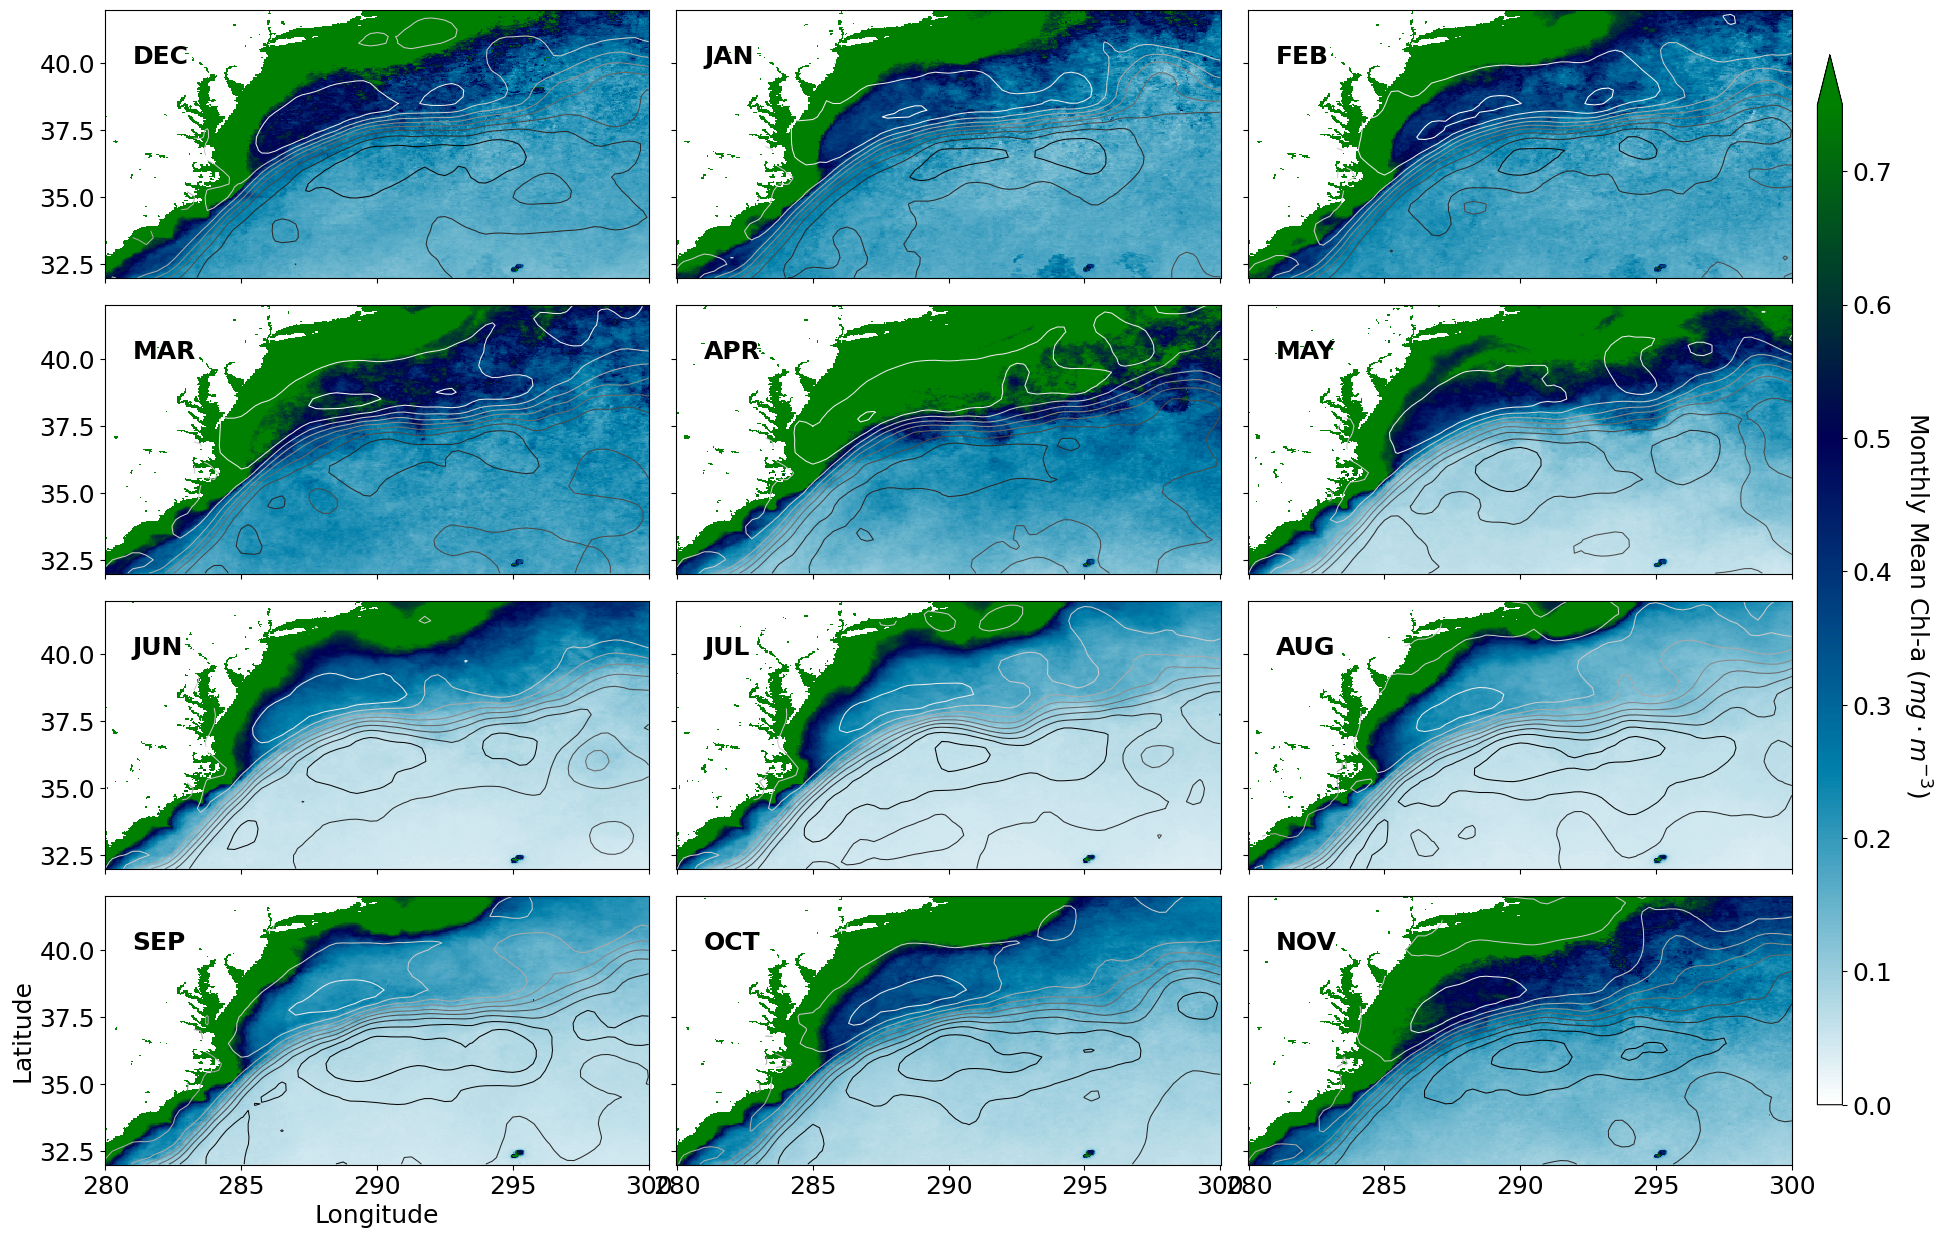

In [13]:
fig,ax = plt.subplots(4,3,figsize=(25,15))
plt.subplots_adjust(wspace=0.05, hspace=0.1) # make plots closer together

month_list = ['01','02','03','04','05','06','07','08','09','10','11','12']
months = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']

def plot_row_by_season(row_ind,array_of_months):
    i = 0
    for m in array_of_months:
        
        chl_avg = month_chl_avg[month_list.index(m)]
        plot = ax[row_ind,i].pcolormesh(chl_lon_edges[chl_lon_inds]+360,chl_lat_edges[chl_lat_inds],np.array(chl_avg)[chl_lat_inds[0],:][:,chl_lon_inds[0]],
                                        cmap='ocean_r',shading='nearest',vmin=0,vmax=0.75)
#        ax[row_ind,i].text(-78,40,months[month_list.index(m)],color='k',fontweight='bold')
        i += 1
    return plot

plot = plot_row_by_season(0,['12','01','02']) # Winter
plot = plot_row_by_season(1,['03','04','05']) # Spring
plot = plot_row_by_season(2,['06','07','08']) # Summer
plot = plot_row_by_season(3,['09','10','11']) # Fall

# Colorbar
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.81, 0.15, 0.01, 0.7]) #[left, bottom, width, height]
fig.colorbar(plot, cax=cbar_ax, extend='max')
cbar_ax.set_ylabel('Monthly Mean Chl-a ($mg\cdot m^{-3}$)', rotation=270)
cbar_ax.get_yaxis().labelpad = 30

def plot_adt_row_by_season(row_ind,array_of_months):
    i = 0
    for m in array_of_months:
        ADT_avg = np.load('/nfs/micklab005/jonesae/NP_2000_to_2020/CMEMS_data/climatology/dt_global_allsat_phy_l4_2010_2019_month_%s_AVG.npy'%(m))
        plot = ax[row_ind,i].contour(sample_sla_lon_edges[lon_inds],sample_sla_lat_edges[lat_inds],np.array(ADT_avg)[lat_inds[0],:][:,lon_inds[0]],
                                        cmap='binary',levels=10,vmin=-0.25,vmax=0.95,linewidths=0.75)
        ax[row_ind,i].text(281,40,months[month_list.index(m)],color='k',fontweight='bold')
        i += 1
    return plot

plot = plot_adt_row_by_season(0,['12','01','02']) # Winter
plot = plot_adt_row_by_season(1,['03','04','05']) # Spring
plot = plot_adt_row_by_season(2,['06','07','08']) # Summer
plot = plot_adt_row_by_season(3,['09','10','11']) # Fall


ax[3,0].set_xlabel('Longitude')
ax[3,0].set_ylabel('Latitude')

for row in range(4):
    for col in range(3):
        if row != 3:
            ax[row,col].set_xticklabels([])
        if col != 0:
            ax[row,col].set_yticklabels([])
        #ax[row,col].grid(True,c='k')

plt.show()

### Interpolate Chl to the CMEMS grid

This will yield a smaller file size and simplify the clustering. First crop chl data and convert from numpy array to xarray dataset.

In [37]:
lon_min,lon_max = 280, 300
lat_min,lat_max = 32, 42

sla_lon_centers = sample_sla.longitude
sla_lat_centers = sample_sla.latitude

sla_lon_inds = np.where((sla_lon_centers >= lon_min) & (sla_lon_centers <= lon_max))
sla_lat_inds = np.where((sla_lat_centers >= lat_min) & (sla_lat_centers <= lat_max))

sla_lon_centers_cropped = sla_lon_centers[sla_lon_inds]
sla_lat_centers_cropped = sla_lat_centers[sla_lat_inds]

In [36]:
month_ADT_avg = []
for m in month_list:
    ADT_avg = np.load('/nfs/micklab005/jonesae/NP_2000_to_2020/CMEMS_data/climatology/dt_global_allsat_phy_l4_2010_2019_month_%s_AVG.npy'%(m))
    month_ADT_avg.append(np.array(ADT_avg)[sla_lat_inds[0],:][:,sla_lon_inds[0]])
print(np.shape(month_ADT_avg))

(12, 40, 80)


In [39]:
sla_ds = xr.Dataset(data_vars={'ADT':(('month', 'latitude', 'longitude'),month_ADT_avg)}, 
                        coords={'month':range(1,13),
                                'latitude':sla_lat_centers_cropped,
                                'longitude':sla_lon_centers_cropped})
sla_ds

<xarray.Dataset> Size: 308kB
Dimensions:    (month: 12, latitude: 40, longitude: 80)
Coordinates:
  * latitude   (latitude) float32 160B 32.12 32.38 32.62 ... 41.38 41.62 41.88
  * longitude  (longitude) float32 320B 280.1 280.4 280.6 ... 299.4 299.6 299.9
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    ADT        (month, latitude, longitude) float64 307kB -0.03917 ... -0.02104

Now chl-a

In [26]:
chl_lon_centers = sample_chl.lon
chl_lat_centers = sample_chl.lat

chl_lon_inds = np.where((chl_lon_centers >= lon_min-360) & (chl_lon_centers <= lon_max-360)) # chl longitude is -180 to 180 
chl_lat_inds = np.where((chl_lat_centers >= lat_min) & (chl_lat_centers <= lat_max))

chl_lon_centers_cropped = chl_lon_centers[chl_lon_inds]+360
chl_lat_centers_cropped = chl_lat_centers[chl_lat_inds]
chl_cropped = np.array(month_chl_avg)[:,chl_lat_inds[0],:][:,:,chl_lon_inds[0]]

In [27]:
print(len(chl_lon_centers_cropped))
print(len(chl_lat_centers_cropped))
print(np.shape(chl_cropped))

480
240
(12, 240, 480)


In [41]:
chl_ds = xr.Dataset(data_vars={'chl':(('month', 'lat', 'lon'),chl_cropped)}, 
                        coords={'month':range(1,13),
                                'lat':chl_lat_centers_cropped,
                                'lon':chl_lon_centers_cropped})
chl_ds

<xarray.Dataset> Size: 6MB
Dimensions:  (month: 12, lat: 240, lon: 480)
Coordinates:
  * lat      (lat) float64 2kB 41.98 41.94 41.9 41.85 ... 32.15 32.1 32.06 32.02
  * lon      (lon) float64 4kB 280.0 280.1 280.1 280.1 ... 299.9 299.9 300.0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    chl      (month, lat, lon) float32 6MB nan nan nan ... 0.1314 0.1339 0.1304

Smooth chl-a to same grid as the ADT

In [46]:
chl_ds_low_res = chl_ds.interp(lat=sla_ds.latitude, lon=sla_ds.longitude, method='linear', kwargs={"fill_value": "extrapolate"}) # fill value extrapolates to the edges of the map
chl_ds_low_res

<xarray.Dataset> Size: 308kB
Dimensions:    (month: 12, latitude: 40, longitude: 80)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    lat        (latitude) float32 160B 32.12 32.38 32.62 ... 41.38 41.62 41.88
    lon        (longitude) float32 320B 280.1 280.4 280.6 ... 299.4 299.6 299.9
  * latitude   (latitude) float32 160B 32.12 32.38 32.62 ... 41.38 41.62 41.88
  * longitude  (longitude) float32 320B 280.1 280.4 280.6 ... 299.4 299.6 299.9
Data variables:
    chl        (month, latitude, longitude) float64 307kB 0.5831 ... 0.4356

In [55]:
chl_ds_low_res = chl_ds_low_res.reset_coords(['lat','lon'], drop=True)

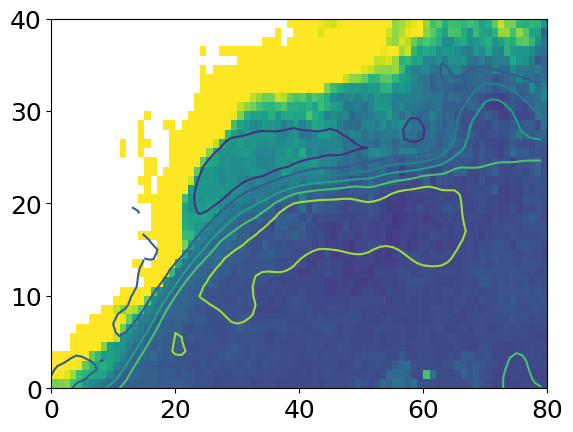

In [51]:
plt.pcolormesh(chl_ds_low_res.chl[0],vmin=0,vmax=0.75)
plt.contour(sla_ds.ADT[0])

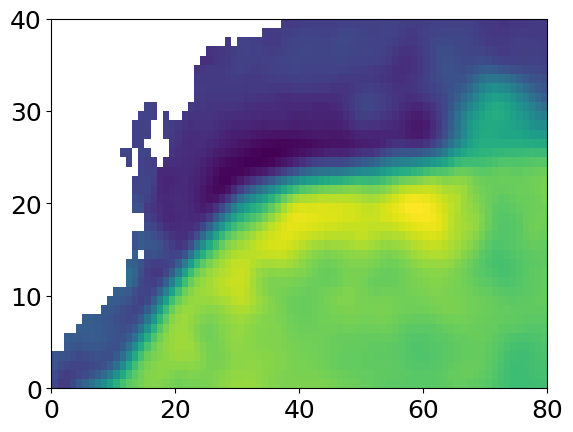

In [49]:
plt.pcolormesh(sla_ds.ADT[0])

### Save Monthly Avg Data

Going to transfer to CryoCloud

In [56]:
save_dir = '/pool001/jonesae/PACEhackweek/'
sla_ds.to_netcdf(save_dir + 'monthly_ADT_avg_2000_to_2020_CMEMS_dt_global_allsat_Gulf_Stream_crop.nc')
chl_ds_low_res.chl.to_netcdf(save_dir + 'monthly_chl_avg_2000_to_2020_OCCCI-4km_GEO_PML_OCx-201612-fv6.0_Gulf_Stream_crop.nc')